<a href="https://colab.research.google.com/github/tkacha467/end-to-end-ml-projects/blob/main/Spambase_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Comparison on Spambase Dataset

Models Used:
- KNN
- Naive Bayes
- Decision Tree
- Random Forest
- SVM

In [1]:
#import Libries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
#mount drive
from google.colab import drive
drive.mount('/content/MyDrive')

Mounted at /content/MyDrive


#Load dataset

In [3]:
df=pd.read_csv("/content/MyDrive/MyDrive/Marwadi_uiniversity/SEM-II/ML/Matereal/18-3/spambase.csv")



In [4]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
df.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


#Split Features & target


In [6]:
X=df.drop('spam',axis=1)
y=df['spam']

# train Test Split


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


#Features Scaling

In [8]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Creates Dictionary To Store all model Result

In [9]:
results = {}


#Navie Bayes

In [10]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_pred = nb_model.predict(X_test_scaled)
results['Naive Bayes'] = accuracy_score(y_test, nb_pred)

print("\ Naive Bayes Accuracy:", results['Naive Bayes'])

\ Naive Bayes Accuracy: 0.8219326818675353


<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1508/4238761368.py:6: SyntaxWarning: invalid escape sequence '\ '
  print("\ Naive Bayes Accuracy:", results['Naive Bayes'])


#Decision Tree (Cart)

In [11]:
cart_model = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_model.fit(X_train_scaled, y_train)
cart_pred = cart_model.predict(X_test_scaled)
results['DT (CART)'] = accuracy_score(y_test, cart_pred)

print("Decision Treeaccuracy:", results['DT (CART)'])

Decision Treeaccuracy: 0.9196525515743756


#Decision Tree ID3

In [12]:
id3_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3_model.fit(X_train_scaled, y_train)
id3_pred = id3_model.predict(X_test_scaled)
results['DT (ID3)'] = accuracy_score(y_test, id3_pred)

print("DecisionTree ID3 Accuracy:", results['DT (ID3)'])


DecisionTree ID3 Accuracy: 0.9315960912052117


#Random Forest

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
results['Random Forest'] = accuracy_score(y_test, rf_pred)

print(" Random Forestaccuracy:", results['Random Forest'])

 Random Forestaccuracy: 0.9554831704668838


#

#Svm

In [14]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
results['SVM'] = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", results['SVM'])

SVM Accuracy: 0.9348534201954397


#Visualization

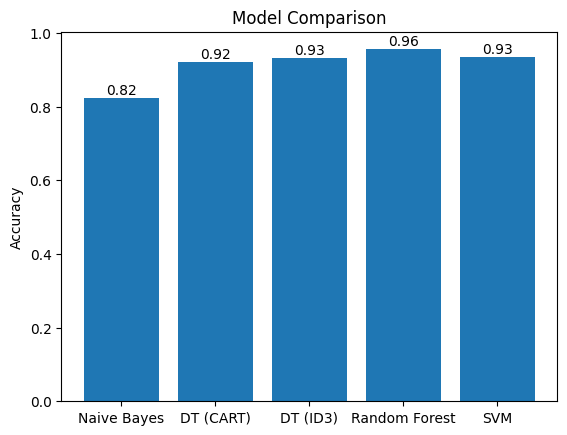

In [15]:

models = list(results.keys())
accuracies = list(results.values())

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [19]:
import pandas as pd

# Create comparison table from the existing 'results' dictionary
# Note: KNN was mentioned in the problem description but not implemented in the code, so it's excluded from this comparison.
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

# Sort results
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("Model Comparison:\n")
print(results_df)

Model Comparison:

           Model  Accuracy
3  Random Forest  0.955483
4            SVM  0.934853
2       DT (ID3)  0.931596
1      DT (CART)  0.919653
0    Naive Bayes  0.821933


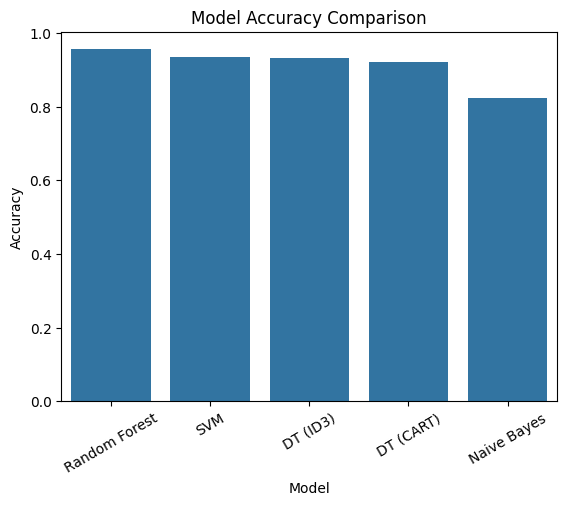

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()